# TDCRPy — Stochastic efficiency: semi-analytical vs optical transport

Compares two detection models at the same fixed free parameter **L**:

| Mode | Parameter | Detection model |
|------|-----------|----------------|
| Semi-analytical | `opticalTransport=False` (default) | Poisson mean-field formula |
| Optical transport | `opticalTransport=True` | Photons sampled → split equally among PMTs → Binomial photoelectron conversion |

Nuclides: **H-3** (pure β⁻, 18.6 keV), **Fe-55** (EC + X-rays), **Co-60** (β⁻ + γ)

> Edit the *Configuration* cell to change L, kB, V or N.

In [1]:
pip install TDCRPy==2.20.12

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from importlib.metadata import version
import tdcrpy.TDCRPy as tm
import tdcrpy.TDCR_model_lib as tl

print(f'TDCRPy {version("TDCRPy")}')

TDCRPy 2.20.11


## ⚙️ Configuration

In [3]:
# ── Physical parameters ──────────────────────────────────────────────────────
L  = 9.0      # free parameter (photons keV⁻¹), fixed
kB = 1.0e-5   # Birks constant (cm keV⁻¹)
V  = 10       # scintillator volume (mL)
N  = 5000     # Monte-Carlo trials per run

# ── Nuclides ────────────────────────────────────────────────────────────────
NUCLIDES = ['H-3', 'Fe-55', 'Co-60']
COLORS   = ['#1f77b4', '#e67e22', '#27ae60']

print(f'L = {L} photons/keV  |  kB = {kB} cm/keV  |  V = {V} mL  |  N = {N}')
print(f'effQuantic = {tl.effQuantic}')

L = 9.0 photons/keV  |  kB = 1e-05 cm/keV  |  V = 10 mL  |  N = 5000
effQuantic = [0.1, 0.1, 0.1]


## 1. Run both models for all nuclides

In [4]:
results = {}   # {rad: {'semi': (S,uS,D,uD,T,uT), 'mc': (S,uS,D,uD,T,uT)}}

for rad in NUCLIDES:
    print(f'\n{rad}')

    # ── Semi-analytical (default) ─────────────────────────────────────────
    print(f'  Semi-analytical ...')
    r_semi = tm.TDCRPy(L, rad, '1', N, kB, V, opticalTransport=False)
    semi = (r_semi[0], r_semi[1], r_semi[2], r_semi[3], r_semi[4], r_semi[5])
    print(f'    eff_S={semi[0]:.5f}±{semi[1]:.5f}  '
          f'eff_D={semi[2]:.5f}±{semi[3]:.5f}  '
          f'eff_T={semi[4]:.5f}±{semi[5]:.5f}')

    # ── Optical transport (full MC) ──────────────────────────────────────
    print(f'  Optical transport ...')
    r_mc = tm.TDCRPy(L, rad, '1', N, kB, V, opticalTransport=True)
    mc = (r_mc[0], r_mc[1], r_mc[2], r_mc[3], r_mc[4], r_mc[5])
    print(f'    eff_S={mc[0]:.5f}±{mc[1]:.5f}  '
          f'eff_D={mc[2]:.5f}±{mc[3]:.5f}  '
          f'eff_T={mc[4]:.5f}±{mc[5]:.5f}')

    results[rad] = {'semi': semi, 'mc': mc}

print('\nDone.')


H-3
  Semi-analytical ...


    eff_S=0.78830±0.00397  eff_D=0.56491±0.00492  eff_T=0.29408±0.00398
  Optical transport ...


    eff_S=0.79060±0.00575  eff_D=0.56140±0.00702  eff_T=0.28640±0.00639

Fe-55
  Semi-analytical ...


    eff_S=0.85711±0.00378  eff_D=0.62807±0.00325  eff_T=0.23769±0.00127
  Optical transport ...


    eff_S=0.85240±0.00502  eff_D=0.62100±0.00686  eff_T=0.22800±0.00593

Co-60
  Semi-analytical ...


    eff_S=0.98144±0.00158  eff_D=0.96620±0.00218  eff_T=0.94116±0.00286
  Optical transport ...


    eff_S=0.98340±0.00181  eff_D=0.97100±0.00237  eff_T=0.94440±0.00324

Done.


## 2. Comparison table

In [5]:
HDR = (f'{"Nuclide":<10} {"Model":<20}'
       f' {"eff_S":>9} {"u(S)":>7}'
       f' {"eff_D":>9} {"u(D)":>7}'
       f' {"eff_T":>9} {"u(T)":>7}')
print(HDR)
print('─' * 80)

for rad in NUCLIDES:
    for label, key in [('Semi-analytical', 'semi'), ('Optical transport', 'mc')]:
        s, us, d, ud, t, ut = results[rad][key]
        print(f'{rad:<10} {label:<20}'
              f' {s:>9.5f} {us:>7.5f}'
              f' {d:>9.5f} {ud:>7.5f}'
              f' {t:>9.5f} {ut:>7.5f}')
    print()

Nuclide    Model                    eff_S    u(S)     eff_D    u(D)     eff_T    u(T)
────────────────────────────────────────────────────────────────────────────────
H-3        Semi-analytical        0.78830 0.00397   0.56491 0.00492   0.29408 0.00398
H-3        Optical transport      0.79060 0.00575   0.56140 0.00702   0.28640 0.00639

Fe-55      Semi-analytical        0.85711 0.00378   0.62807 0.00325   0.23769 0.00127
Fe-55      Optical transport      0.85240 0.00502   0.62100 0.00686   0.22800 0.00593

Co-60      Semi-analytical        0.98144 0.00158   0.96620 0.00218   0.94116 0.00286
Co-60      Optical transport      0.98340 0.00181   0.97100 0.00237   0.94440 0.00324



## 3. Comparison plots

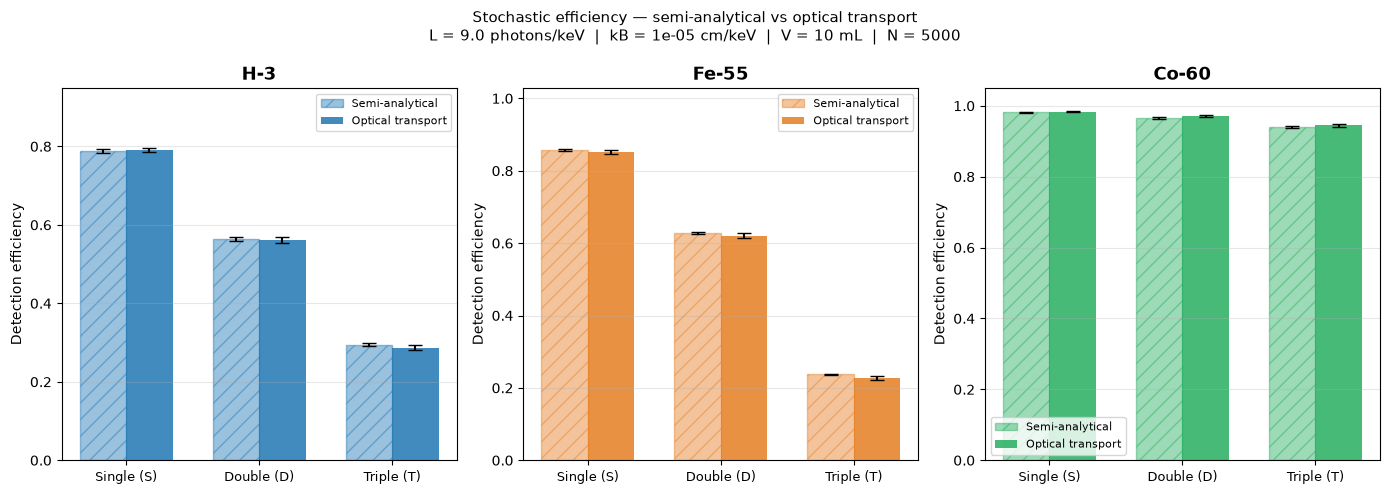

Figure saved.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(
    f'Stochastic efficiency — semi-analytical vs optical transport\n'
    f'L = {L} photons/keV  |  kB = {kB} cm/keV  |  V = {V} mL  |  N = {N}',
    fontsize=11)

labels = ['Single (S)', 'Double (D)', 'Triple (T)']
x = np.arange(3)
w = 0.35

for ax, rad, col in zip(axes, NUCLIDES, COLORS):
    s_semi  = results[rad]['semi']
    s_mc    = results[rad]['mc']

    vals_semi = [s_semi[0], s_semi[2], s_semi[4]]
    errs_semi = [s_semi[1], s_semi[3], s_semi[5]]
    vals_mc   = [s_mc[0],   s_mc[2],   s_mc[4]]
    errs_mc   = [s_mc[1],   s_mc[3],   s_mc[5]]

    ax.bar(x - w/2, vals_semi, w, yerr=errs_semi, capsize=5,
           color=col, alpha=0.45, hatch='//', edgecolor=col,
           label='Semi-analytical')
    ax.bar(x + w/2, vals_mc,   w, yerr=errs_mc,   capsize=5,
           color=col, alpha=0.85, label='Optical transport')

    ax.set_title(rad, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel('Detection efficiency')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    ymax = max(max(vals_semi), max(vals_mc))
    ax.set_ylim(0, min(ymax * 1.2, 1.05) if ymax <= 1 else ymax * 1.1)

plt.tight_layout()
plt.savefig('opticalTransport_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 4. TDCR ratio (T/D) comparison

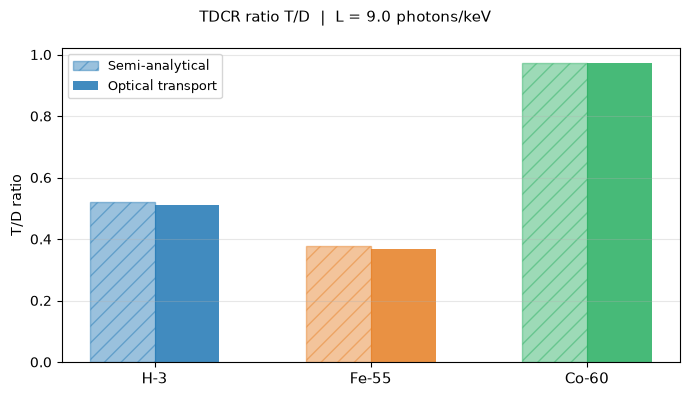

Figure saved.


In [7]:
fig2, ax2 = plt.subplots(figsize=(7, 4))
fig2.suptitle(f'TDCR ratio T/D  |  L = {L} photons/keV', fontsize=11)

bar_x = np.arange(len(NUCLIDES))
w2 = 0.3

tdcr_semi = []
tdcr_mc   = []
for rad in NUCLIDES:
    s, us, d, ud, t, ut = results[rad]['semi']
    tdcr_semi.append(t / d if d > 0 else 0)
    s, us, d, ud, t, ut = results[rad]['mc']
    tdcr_mc.append(t / d if d > 0 else 0)

ax2.bar(bar_x - w2/2, tdcr_semi, w2,
        color=COLORS, alpha=0.45, hatch='//', edgecolor=COLORS,
        label='Semi-analytical')
ax2.bar(bar_x + w2/2, tdcr_mc,   w2,
        color=COLORS, alpha=0.85,
        label='Optical transport')

ax2.set_xticks(bar_x)
ax2.set_xticklabels(NUCLIDES, fontsize=11)
ax2.set_ylabel('T/D ratio')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('opticalTransport_TDCR.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')